# Demo for the ProblemsSolvers class.

This script is intended to help with debugging problems and solvers.

It create problem-solver groups (using the directory) and runs multiple macroreplications of each problem-solver pair.

## Append SimOpt Path

Since the notebook is stored in simopt/notebooks, we need to append the parent simopt directory to the system path to import the necessary modules later on.

In [1]:
import sys
from pathlib import Path

# Take the current directory, find the parent, and add it to the system path
sys.path.append(str(Path.cwd().parent))

## Configuration Parameters

This section defines the core parameters for the demo.

To query model/problem/solver names, run `python scripts/list_directories.py`

In [2]:
#set up san arcs

import numpy as np


# ============================================================
# Network 1: Default SAN network
# ============================================================

arcs_1 = [
    (1, 2),
    (1, 3),
    (2, 3),
    (2, 4),
    (2, 6),
    (3, 6),
    (4, 5),
    (4, 7),
    (5, 6),
    (5, 8),
    (6, 9),
    (7, 8),
    (8, 9),
]

costs_1 = (
    1.0, 1.0, 1.0, 1.0, 1.0,
    1.0, 1.0, 1.0, 1.0, 1.0,
    1.0, 1.0, 1.0,
)


# ============================================================
# Network 2: Small diamond
# Early arcs are expensive
# ============================================================

arcs_2 = [
    (1, 2),
    (1, 3),
    (2, 4),
    (3, 4),
    (2, 5),
    (3, 5),
    (4, 6),
    (5, 6),
]

costs_2 = (
    3.0, 3.0,      # arcs out of source
    2.0, 2.0,
    2.0, 2.0,
    1.0, 1.0,      # arcs into sink
)


# ============================================================
# Network 3: Deep network with shortcuts
# Later arcs are more expensive
# ============================================================

arcs_3 = [
    (1, 2),
    (2, 3),
    (3, 4),
    (4, 5),
    (5, 6),
    (6, 7),
    (7, 8),
    (1, 4),   # shortcut
    (2, 6),   # shortcut
    (4, 8),   # shortcut
]

costs_3 = (
    0.75,
    1.00,
    1.00,
    1.50,
    2.00,
    2.50,
    3.00,
    0.75,
    1.25,
    2.50,
)


# ============================================================
# Network 4: Wide parallel network
# Alternating low/high arc costs
# ============================================================

arcs_4 = [
    (1, 2),
    (1, 3),
    (1, 4),

    (2, 5),
    (2, 6),

    (3, 5),
    (3, 6),

    (4, 6),
    (4, 7),

    (5, 8),
    (6, 8),
    (7, 8),
]

costs_4 = (
    0.5, 2.0, 0.5,
    2.0, 0.5,
    2.0, 0.5,
    2.0, 0.5,
    2.0, 0.5, 2.0,
)


# ============================================================
# Network 5: Larger mesh
# More heterogeneous cost structure
# ============================================================

arcs_5 = [
    (1, 2),
    (1, 3),
    (1, 4),

    (2, 5),
    (2, 6),

    (3, 5),
    (3, 6),
    (3, 7),

    (4, 6),
    (4, 7),

    (5, 8),

    (6, 8),
    (6, 9),

    (7, 9),

    (8, 10),
    (9, 10),
]

costs_5 = (
    1.0, 1.0, 1.0,
    1.5, 3.0,
    1.5, 3.0, 1.5,
    3.0, 1.5,
    1.0,
    2.5, 3.0,
    2.5,
    1.0, 1.0,
)

In [3]:
def make_san_problem_factors(
    arcs,
    num_nodes,
    arc_costs,
    budget=3000,
    x0_value=8.0,
    cost_multiplier=1.25,
):
    """Build matching SAN model/problem factors for a network."""

    n_arcs = len(arcs)

    arc_costs = tuple(float(c) for c in arc_costs)

    if len(arc_costs) != n_arcs:
        raise ValueError(
            f"Need one cost per arc: "
            f"{n_arcs} arcs but {len(arc_costs)} costs."
        )

    # Model must start with an arc_means vector of correct dimension.
    arc_means = (1.0,) * n_arcs

    # Solver starting point.
    initial_solution = (x0_value,) * n_arcs

    # Cost at x0:
    #
    #     sum_i c_i / x_i
    #
    initial_cost = sum(
        c / x0_value
        for c in arc_costs
    )

    # Makes all five starting points comparably infeasible.
    #
    # At x0:
    #     sum(c_i / x_i) < total_cost
    #
    total_cost = cost_multiplier * initial_cost

    return {
        "budget": budget,
        "total_cost": total_cost,

        # Problem factors
        "initial_solution": initial_solution,
        "arc_costs": arc_costs,

        # Model factors
        "arcs": arcs,
        "num_nodes": num_nodes,
        "arc_means": arc_means,
    }

In [4]:
case_1 = make_san_problem_factors(
    arcs=arcs_1,
    num_nodes=9,
    arc_costs=costs_1,
)

case_2 = make_san_problem_factors(
    arcs=arcs_2,
    num_nodes=6,
    arc_costs=costs_2,
)

case_3 = make_san_problem_factors(
    arcs=arcs_3,
    num_nodes=8,
    arc_costs=costs_3,
)

case_4 = make_san_problem_factors(
    arcs=arcs_4,
    num_nodes=8,
    arc_costs=costs_4,
)

case_5 = make_san_problem_factors(
    arcs=arcs_5,
    num_nodes=10,
    arc_costs=costs_5,
)

In [5]:
# ============================================================
# Solvers
# ============================================================

solver_abbr_names = [
    "SQPASTRODF",
    "COBYQA",
]

solver_factors = [
    {
        "feas_tol": 1e-5,
        "easy_solve": True,
        "use_gradients": False,
        "sampling_method": "adaptive",
        "ps_sufficient_reduction": 0,
        "mu": 0.1,
        "a_normal": 0.9,
        "a_tangent": 0.1,
        "eta_2": 0.5,
        "gamma_1": 3,
        "sigma_min": 10,
        "reuse_interpolation_set": True,
        "recenter_mode": "shift",
        "theta_decrease": 0.9999,
        "dist_threshold": 20,
        "delta_0": 1,
    },
    {
        "sample_size": 5,
        "feas_tol": 1e-5,
    },
]


# ============================================================
# SAN problems
# ============================================================

problem_abbr_names = [
    "SAN-3",
    "SAN-3",
    "SAN-3",
    "SAN-3",
    "SAN-3",
]

problem_renames = [
    "SAN-Default-13",
    "SAN-Diamond-8",
    "SAN-Deep-10",
    "SAN-Wide-12",
    "SAN-Mesh-16",
]

problem_factors = [
    case_1,
    case_2,
    case_3,
    case_4,
    case_5,
]


# ============================================================
# Experiment size
# ============================================================

num_macroreps = 10
num_postreps = 50
num_postreps_init_opt = 50

In [6]:
# Initialize an instance of the experiment class.
from simopt.experiment_base import ProblemsSolvers

mymetaexperiment = ProblemsSolvers(
    solver_names=solver_abbr_names, 
    problem_names=problem_abbr_names, 
    solver_factors = solver_factors, 
    problem_factors = problem_factors,
    #solver_renames = solver_renames
)

# Write to log file.
mymetaexperiment.log_group_experiment_results()

In [7]:
# Run a fixed number of macroreplications of each solver on each problem.
mymetaexperiment.run(n_macroreps=num_macroreps)

In [8]:
print("Post-processing results.")
# Run a fixed number of postreplications at all recommended solutions.
mymetaexperiment.post_replicate(n_postreps=num_postreps)

Post-processing results.


In [9]:
print("Post-normalizing results.")

# Find an optimal solution x* for normalization.
mymetaexperiment.post_normalize(n_postreps_init_opt=num_postreps_init_opt)

Post-normalizing results.


In [10]:
#mymetaexperiment.report_group_statistics()

In [11]:
# Produce basic plots.

from simopt.experiment_base import (
    plot_area_scatterplots,  # noqa: F401
    plot_feasibility_progress,  # noqa: F401
    plot_progress_curves,  # noqa: F401
    plot_solvability_cdfs,  # noqa: F401
    plot_solvability_profiles,  # noqa: F401
    plot_terminal_feasibility,  # noqa: F401
    plot_terminal_progress,  # noqa: F401
    plot_terminal_scatterplots, 
    plot_det_feasibility,
    plot_det_terminal_feasibility,
    PlotType # noqa: F401
)


In [12]:
print(mymetaexperiment.experiments[0][0])

Plot saved to [WindowsPath('C:/Users/nikki/GitHub/simopt/notebooks/experiments/2026-08-18_09-49-06/plots/SOLVER_SET_SAN-3_all_prog_curves_unnorm.png')]
Plotting complete!


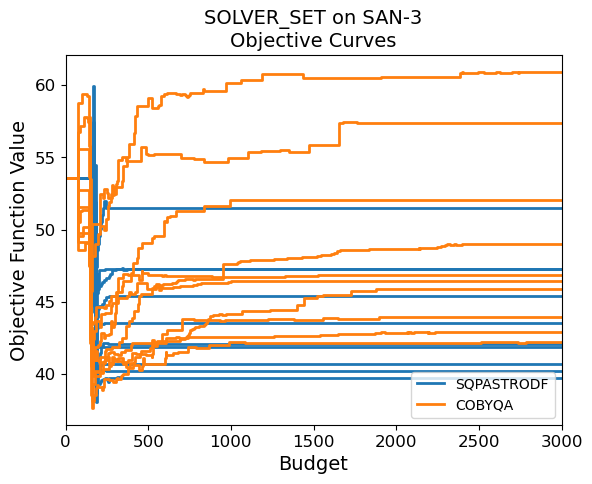

In [13]:
def _print_path(plot_path: list[Path]) -> None:
    print(f"Plot saved to {plot_path!s}")


_print_path(
    plot_progress_curves(
        experiments=[mymetaexperiment.experiments[0][0], mymetaexperiment.experiments[1][0] ]  , all_in_one = True, plot_type=PlotType.ALL, normalize=False,  save_as_pickle = True,
    )
)

print("Plotting complete!")

In [14]:
def _print_path(plot_path: list[Path]) -> None:
    print(f"Plot saved to {plot_path!s}")


_print_path(
    plot_terminal_progress(
        experiments=mymetaexperiment.experiments[0], normalize = False
    )
)

print("Plotting complete!")

ValueError: All experiments must have the same problem.

In [ ]:
def _print_path(plot_path: list[Path]) -> None:
    print(f"Plot saved to {plot_path!s}")


_print_path(
    plot_det_feasibility(
        experiments=mymetaexperiment.experiments,  sym_log = False, score_type = "norm", feas_tol_upper = 1e-2, feas_tol_lower = 1e-5, save_as_pickle=True, log_scale=True,
    )
)

print("Plotting complete!")

Plot saved to [WindowsPath('C:/Users/nikki/GitHub/simopt/notebooks/experiments/2026-08-18_09-49-06/plots/SOLVER_SET_SAN-3_det_feasibility_progress_unnorm.png'), WindowsPath('C:/Users/nikki/GitHub/simopt/notebooks/experiments/2026-08-18_09-49-06/plots/SOLVER_SET_SAN-3_det_feasibility_progress_unnorm (1).png'), WindowsPath('C:/Users/nikki/GitHub/simopt/notebooks/experiments/2026-08-18_09-49-06/plots/SOLVER_SET_SAN-3_det_feasibility_progress_unnorm (1) (2).png'), WindowsPath('C:/Users/nikki/GitHub/simopt/notebooks/experiments/2026-08-18_09-49-06/plots/SOLVER_SET_SAN-3_det_feasibility_progress_unnorm (1) (2) (3).png'), WindowsPath('C:/Users/nikki/GitHub/simopt/notebooks/experiments/2026-08-18_09-49-06/plots/SOLVER_SET_SAN-3_det_feasibility_progress_unnorm (1) (2) (3) (4).png')]
Plotting complete!


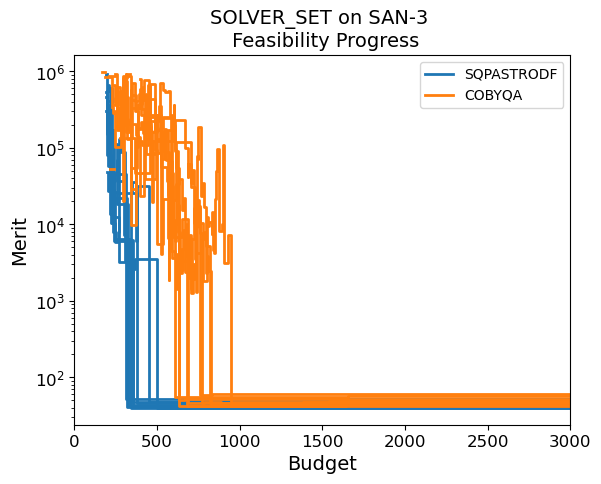

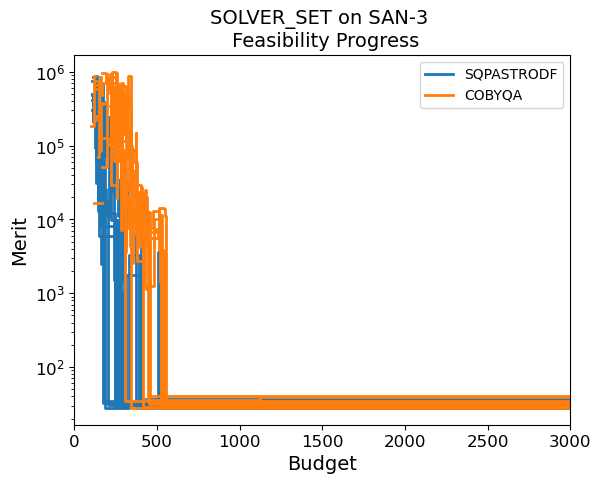

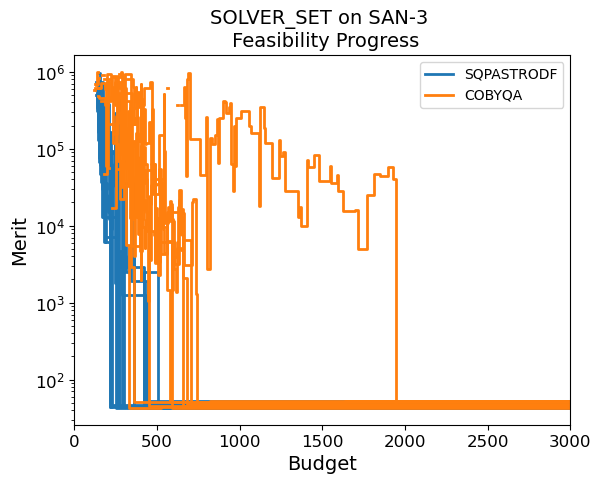

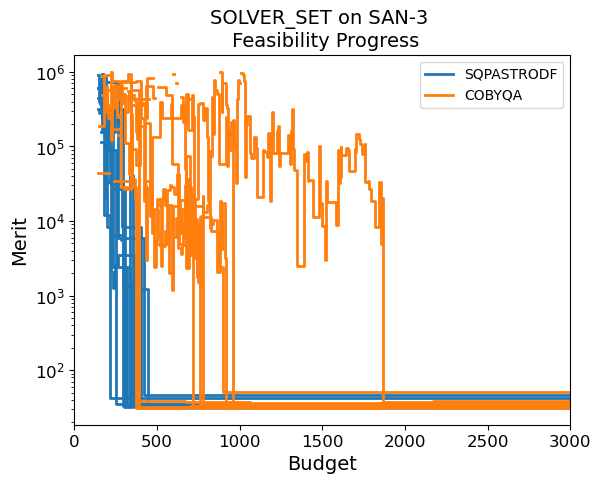

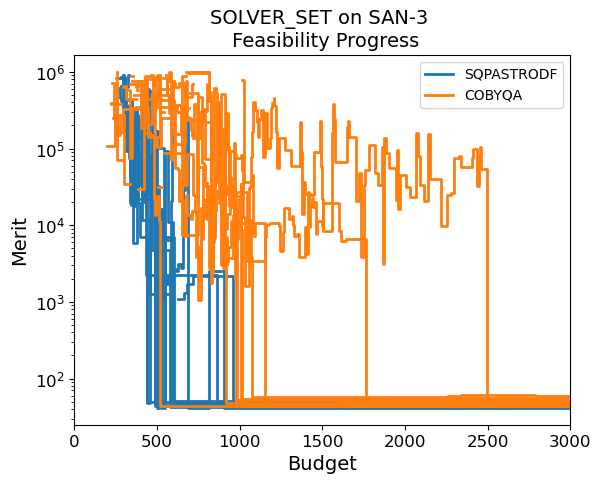

In [17]:
def _print_path(plot_path: list[Path]) -> None:
    print(f"Plot saved to {plot_path!s}")


_print_path(
    plot_det_feasibility(
        experiments=mymetaexperiment.experiments, 
        log_scale = True, 
        score_type = "objective", 
        obj_const = 1e8, 
        feas_tol_upper = 1e-2,
        feas_tol_lower = 1e-5,
        save_as_pickle = True,
    )
)

print("Plotting complete!")

Plot saved to [WindowsPath('C:/Users/nikki/GitHub/simopt/notebooks/experiments/2026-08-18_09-49-06/plots/SOLVER_SET_SAN-3_det_feasibility_scatter_unnorm (1) (2) (3) (4) (5).png'), WindowsPath('C:/Users/nikki/GitHub/simopt/notebooks/experiments/2026-08-18_09-49-06/plots/SOLVER_SET_SAN-3_det_feasibility_scatter_unnorm (1) (2) (3) (4) (5) (6).png'), WindowsPath('C:/Users/nikki/GitHub/simopt/notebooks/experiments/2026-08-18_09-49-06/plots/SOLVER_SET_SAN-3_det_feasibility_scatter_unnorm (1) (2) (3) (4) (5) (6) (7).png'), WindowsPath('C:/Users/nikki/GitHub/simopt/notebooks/experiments/2026-08-18_09-49-06/plots/SOLVER_SET_SAN-3_det_feasibility_scatter_unnorm (1) (2) (3) (4) (5) (6) (7) (8).png'), WindowsPath('C:/Users/nikki/GitHub/simopt/notebooks/experiments/2026-08-18_09-49-06/plots/SOLVER_SET_SAN-3_det_feasibility_scatter_unnorm (1) (2) (3) (4) (5) (6) (7) (8) (9).png')]
Plotting complete!


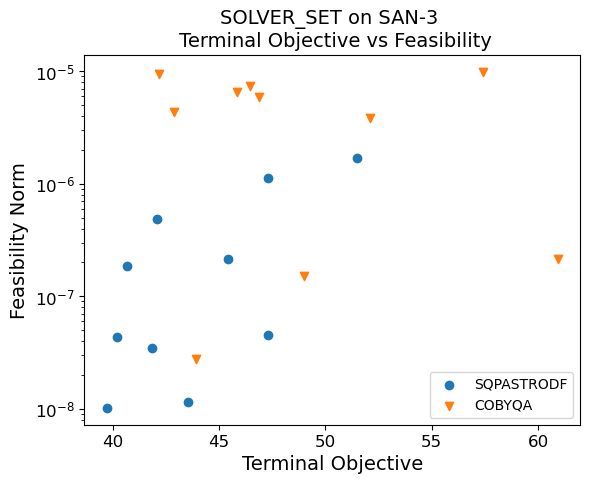

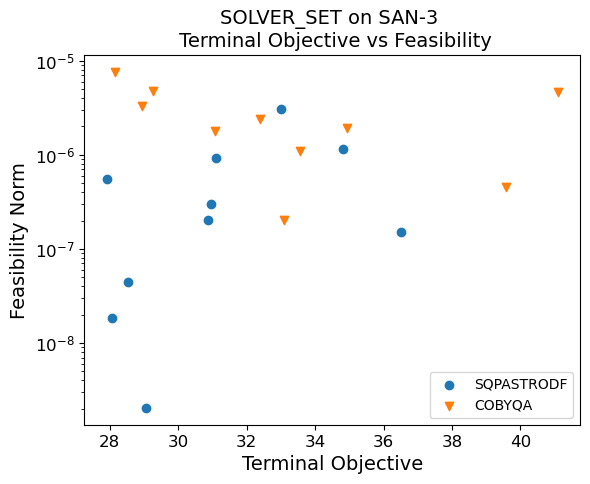

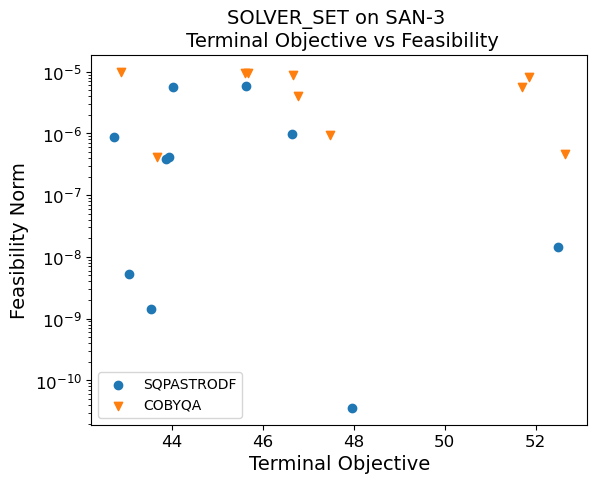

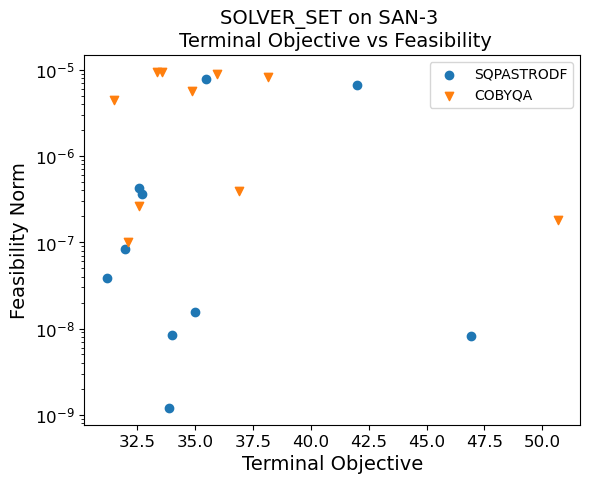

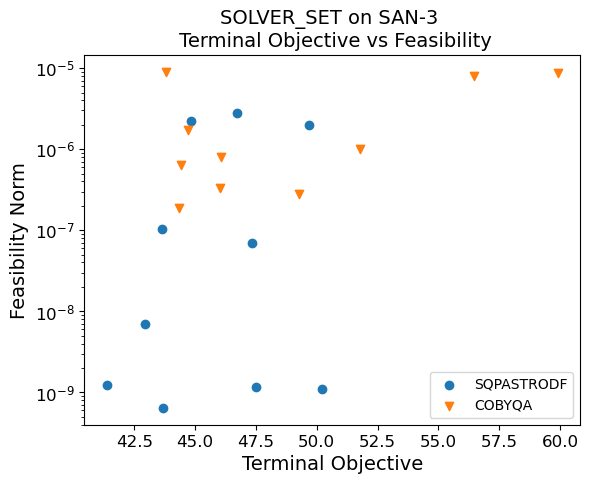

In [16]:
def _print_path(plot_path: list[Path]) -> None:
    print(f"Plot saved to {plot_path!s}")


_print_path(
    plot_det_terminal_feasibility(
        experiments=mymetaexperiment.experiments, all_in_one = True, plot_conf_ints = False, score_type = "norm", 
        feas_tol = 1e-5,
        log_scale = True,
        sym_log= False,
        floor_feas=False,
        plot_zero = False,
        save_as_pickle=True,
    )
)

print("Plotting complete!")

In [ ]:
def _print_path(plot_path: list[Path]) -> None:
    print(f"Plot saved to {plot_path!s}")


_print_path(
    plot_det_terminal_feasibility(
        experiments=mymetaexperiment.experiments, all_in_one = True, plot_conf_ints = True, sym_log = True, score_type = "norm", feas_tol = 1e-2, log_scale=True
    )
)

print("Plotting complete!")

In [ ]:
def _print_path(plot_path: list[Path]) -> None:
    print(f"Plot saved to {plot_path!s}")


_print_path(
    plot_det_terminal_feasibility(
        experiments=mymetaexperiment.experiments, all_in_one = True, score_type = "norm", save_as_pickle = True, plot_conf_ints = True, feas_tol = 1e-4,  plot_zero = False, log_scale = False
    )
)

print("Plotting complete!")